/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Common token example: ' the' count: 6543 norm: 2.6701565
Rare token example:   '6' count: 1 norm: 2.8996277


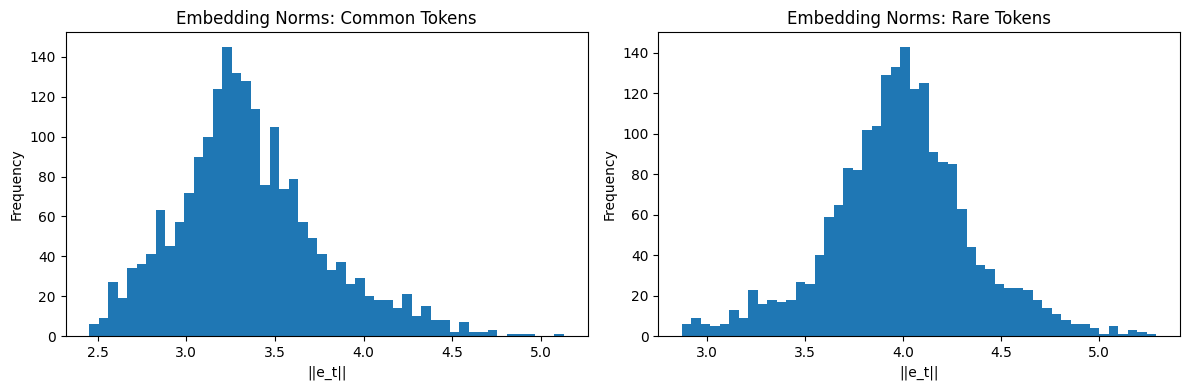

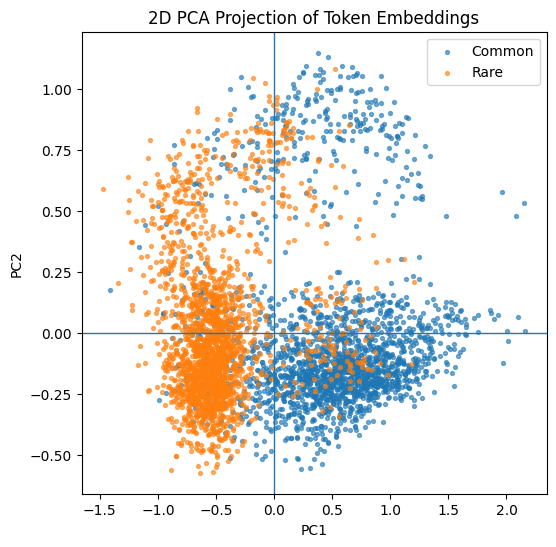


Tokens closest to origin in PCA(2D):
  id=14307  count=      10  norm=3.429  token=' Between'
  id= 7945  count=      16  norm=3.003  token=' Despite'
  id=11527  count=      36  norm=3.484  token=' cave'
  id= 7299  count=      10  norm=3.510  token=' Stan'
  id=  165  count=       1  norm=3.636  token='�'
  id=12067  count=      26  norm=3.543  token=' cm'
  id=  564  count=      29  norm=3.806  token=' �'
  id=10564  count=      11  norm=3.813  token=' dies'
  id=14685  count=      14  norm=3.643  token=' Charlotte'
  id=12168  count=      10  norm=2.978  token=' Several'

Tokens farthest from origin in PCA(2D):
  id=  284  count=    2180  norm=2.523  token=' to'
  id=  357  count=     632  norm=2.605  token=' ('
  id=  366  count=    1232  norm=2.794  token=' "'
  id=  287  count=    2245  norm=2.465  token=' in'
  id=  257  count=    1944  norm=2.573  token=' a'
  id=   13  count=     499  norm=3.011  token='.'
  id=  290  count=    2979  norm=2.603  token=' and'
  id=   12  coun

In [ ]:
# If needed:
# !pip -q install transformers datasets torch matplotlib scikit-learn

import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.decomposition import PCA

# -----------------------------
# 1) Load GPT-2 + embedding matrix
# -----------------------------
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Token embedding matrix: [vocab_size, embed_dim]
E = model.transformer.wte.weight.detach().cpu()  # torch.Tensor
vocab_size, embed_dim = E.shape
print("Embedding matrix shape:", E.shape)

# Norm per token id: [vocab_size]
norms = torch.linalg.norm(E, dim=1).numpy()

# -----------------------------
# 2) Get token frequencies from a corpus
# -----------------------------
# WikiText-103 (raw): gives plain text; we'll tokenize and count token ids
ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="train")

# To keep this quick, limit to first N documents (increase for better estimates)
N_DOCS = 2000
texts = ds["text"][:N_DOCS]

# Tokenize in chunks to avoid huge memory
counts = np.zeros(vocab_size, dtype=np.int64)

BATCH = 64
for i in range(0, len(texts), BATCH):
    batch = texts[i:i+BATCH]
    enc = tokenizer(batch, add_special_tokens=False, return_attention_mask=False)
    for ids in enc["input_ids"]:
        # update counts
        ids = np.asarray(ids, dtype=np.int64)
        if ids.size:
            # bincount on ids then add
            counts[:ids.max()+1] += np.bincount(ids, minlength=ids.max()+1)

# Keep only tokens that appear at least once (avoid "never seen" in sample)
present = np.where(counts > 0)[0]

# -----------------------------
# 3) Choose "common" and "rare" tokens
# -----------------------------
K = 2000  # number of tokens in each group (tune up/down)
present_sorted = present[np.argsort(counts[present])]  # ascending by frequency

rare_ids = present_sorted[:K]
common_ids = present_sorted[-K:]

rare_norms = norms[rare_ids]
common_norms = norms[common_ids]

print("Common token example:", repr(tokenizer.decode([common_ids[-1]])), "count:", counts[common_ids[-1]], "norm:", norms[common_ids[-1]])
print("Rare token example:  ", repr(tokenizer.decode([rare_ids[0]])), "count:", counts[rare_ids[0]], "norm:", norms[rare_ids[0]])

# -----------------------------
# 4) Plot histograms of norms
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(common_norms, bins=50)
plt.title("Embedding Norms: Common Tokens")
plt.xlabel("||e_t||")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(rare_norms, bins=50)
plt.title("Embedding Norms: Rare Tokens")
plt.xlabel("||e_t||")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) 2D PCA projection + "distance to origin"
# -----------------------------
# PCA on the selected token embeddings for visualization
sel_ids = np.concatenate([common_ids, rare_ids])
X = E[sel_ids].numpy()

pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)  # [2K, 2]

# distance from origin in the 2D projection (proxy for norm after projection)
dist2 = np.linalg.norm(X2, axis=1)

plt.figure(figsize=(6,6))
plt.scatter(X2[:K,0], X2[:K,1], s=8, alpha=0.6, label="Common")
plt.scatter(X2[K:,0], X2[K:,1], s=8, alpha=0.6, label="Rare")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("2D PCA Projection of Token Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# -----------------------------
# 6) Inspect tokens near vs far from origin (in 2D)
# -----------------------------
# Note: This is "near/far" in the PCA plane, not the full 768D space.
order = np.argsort(dist2)
near = sel_ids[order[:10]]
far  = sel_ids[order[-10:]]

print("\nTokens closest to origin in PCA(2D):")
for tid in near:
    print(f"  id={tid:5d}  count={counts[tid]:8d}  norm={norms[tid]:.3f}  token={repr(tokenizer.decode([int(tid)]))}")

print("\nTokens farthest from origin in PCA(2D):")
for tid in far:
    print(f"  id={tid:5d}  count={counts[tid]:8d}  norm={norms[tid]:.3f}  token={repr(tokenizer.decode([int(tid)]))}")


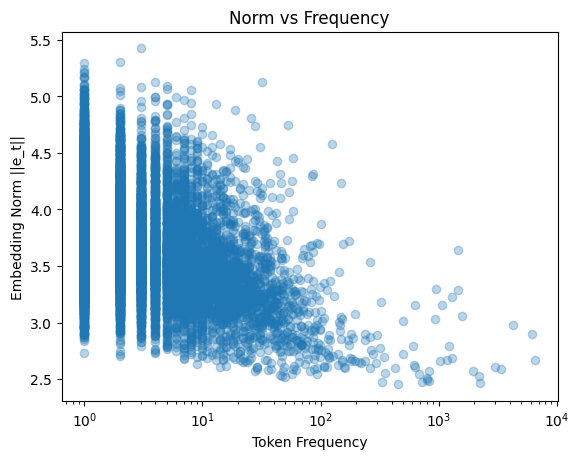

In [ ]:
plt.scatter(counts[present], norms[present], alpha=0.3)
plt.xscale("log")
plt.xlabel("Token Frequency")
plt.ylabel("Embedding Norm ||e_t||")
plt.title("Norm vs Frequency")
plt.show()


In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(counts[present], norms[present])
print("Spearman correlation:", rho)


Spearman correlation: -0.3961236286091796


In [ ]:
tokenizer.encode('the')

[1169]

In [ ]:
emb_mat = model.transformer.wte.weight.detach()

In [ ]:
torch.norm(emb_mat[tokenizer.encode('the'),:])

tensor(2.9960)

In [ ]:
torch.norm(emb_mat[tokenizer.encode('visualizer'),:])

tensor(5.9768)

In [14]:
the_token_id = tokenizer.encode('visualizer')[0]
the_count = counts[the_token_id]
print(f"Occurrences of 'the' in the dataset: {the_count}")

Occurrences of 'the' in the dataset: 0
